In [7]:
from sentence_transformers import SentenceTransformer

model = SentenceTransformer(
    "dragonkue/BGE-m3-ko",
    device="cpu"
)

Loading weights:   0%|          | 0/391 [00:00<?, ?it/s]

### 군집
- 질문-문서가 아닌 문서끼리 비교할 때 하는 작업

In [2]:
import pandas as pd
from sklearn.cluster import KMeans

In [6]:
data = pd.read_csv("../data/11-1_뉴스정제.csv")

df = data.groupby("카테고리").head(150).reset_index(drop=True)
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 300 entries, 0 to 299
Data columns (total 6 columns):
 #   Column  Non-Null Count  Dtype
---  ------  --------------  -----
 0   제목      300 non-null    str  
 1   본문      300 non-null    str  
 2   카테고리    300 non-null    str  
 3   요약      300 non-null    str  
 4   출처URL   300 non-null    str  
 5   정제본문    300 non-null    str  
dtypes: str(6)
memory usage: 14.2 KB


In [10]:
doc_vecs = model.encode(df['정제본문'].tolist(), 
                        normalize_embeddings=True, 
                        show_progress_bar=True,
                        batch_size=4)

Batches:   0%|          | 0/75 [00:00<?, ?it/s]

In [11]:
doc_vecs.shape

(300, 1024)

In [12]:
df['카테고리'].unique()

<StringArray>
['경제', 'IT과학']
Length: 2, dtype: str

### K-means 클러스터링
- 지정한 개수만큼 그룹으로 묶는 방식
- 거리 기반

In [16]:
km = KMeans(n_clusters=2, random_state=42, n_init=10).fit(doc_vecs)

df['군집'] = km.labels_
df['군집'].value_counts()

군집
0    209
1     91
Name: count, dtype: int64

In [14]:
df['카테고리'].value_counts()

카테고리
경제      150
IT과학    150
Name: count, dtype: int64

### 군집과 카테고리가 얼마나 맞는지

In [ ]:
pd.crosstab(df['군집'], df['카테고리'])
# 결과 관찰하면, 경제는 0과 1 완전히 나누어져 있다... 뭔가 대책이 필요

카테고리,IT과학,경제
군집,,
0,135,74
1,15,76


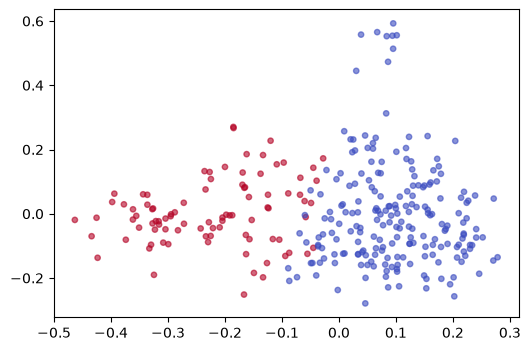

In [23]:
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt

coords = PCA(n_components=2).fit_transform(doc_vecs)    # 벡터를 2차원으로 줄임

plt.figure(figsize=(6,4))
plt.scatter(coords[:,0], coords[:,1], c=df['군집'], cmap="coolwarm", s=15, alpha=0.6)
plt.show()

In [26]:
km = KMeans(n_clusters=3, random_state=42, n_init=10).fit(doc_vecs)

df['군집3'] = km.labels_
df['군집3'].value_counts()

군집3
0    193
2     98
1      9
Name: count, dtype: int64

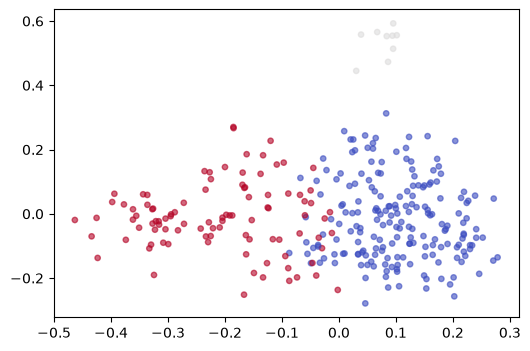

In [28]:
coords = PCA(n_components=2).fit_transform(doc_vecs)    # 벡터를 2차원으로 줄임

plt.figure(figsize=(6,4))
plt.scatter(coords[:,0], coords[:,1], c=df['군집3'], cmap="coolwarm", s=15, alpha=0.6)
plt.show()

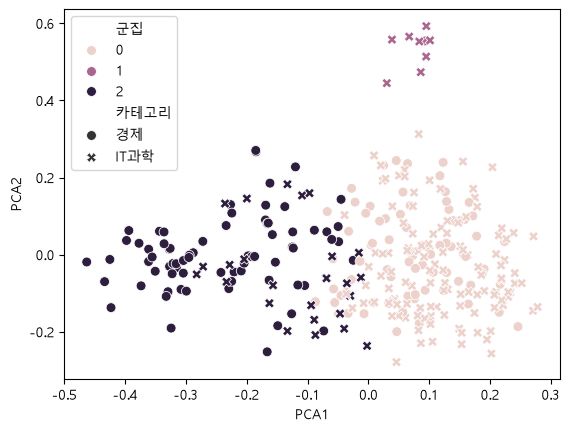

In [29]:
import seaborn as sns

plt.rcParams["font.family"] = "Malgun Gothic"   # 한글 깨짐 방지(윈도우 기본 폰트)
plt.rcParams["axes.unicode_minus"] = False

coords = PCA(n_components=2).fit_transform(doc_vecs)

plot_df = pd.DataFrame({
    "PCA1": coords[:, 0],
    "PCA2": coords[:, 1],
    "군집": df["군집3"],
    "카테고리": df["카테고리"]
})

sns.scatterplot(
    data=plot_df,
    x="PCA1",
    y="PCA2",
    hue="군집",
    style="카테고리",
    s=50
)

plt.show()